## Prediction test with provabgs catalogs

In [ ]:
import sys 
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("..")
from utils import DataProcessor, FeatureExtractor

# check the gpu
import torch
print(torch.cuda.is_available()) ## gpu available
print(torch.cuda.get_device_name(0)) ## gpu info

%load_ext autoreload
%autoreload 2

True
NVIDIA A40
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load data and processor

In [37]:
dataset = "provabgs" ##
Loader = DataLoader(dataset = dataset)
BATCH_SIZE = 32
data = Loader.load_data()

In [38]:
data

TARGETID,RA,DEC,Z_HP,ZERR,TSNR2_BGS,MAG_G,MAG_R,MAG_Z,MAG_W1,FIBMAG_R,HPIX_64,PROVABGS_MCMC,PROVABGS_THETA_BF,PROVABGS_Z_MAX,PROVABGS_LOGMSTAR,SCHLEGEL_COLOR,PROVABGS_W_ZFAIL,PROVABGS_W_FIBASSIGN,IS_BGS_BRIGHT,IS_BGS_FAINT,LOG_MSTAR,LOG_Z_MW,TAGE_MW,sSFR,object_id,desi_spectrum_flux,desi_spectrum_ivar,desi_spectrum_lsf_sigma,desi_spectrum_lambda,desi_spectrum_mask,desi_Z,desi_ZERR,desi_EBV,desi_FLUX_G,desi_FLUX_R,desi_FLUX_Z,desi_FLUX_IVAR_G,desi_FLUX_IVAR_R,desi_FLUX_IVAR_Z,desi_FIBERFLUX_G,desi_FIBERFLUX_R,desi_FIBERFLUX_Z,desi_FIBERTOTFLUX_G,desi_FIBERTOTFLUX_R,desi_FIBERTOTFLUX_Z,desi_object_id,desi_ra_center,desi_dec_center,desi_ra,desi_dec,legacysurvey_image_flux,legacysurvey_image_ivar,legacysurvey_image_mask,legacysurvey_image_psf_fwhm,legacysurvey_image_scale,legacysurvey_image_rgb,legacysurvey_image_array,legacysurvey_object_mask,legacysurvey_EBV,legacysurvey_FLUX_G,legacysurvey_FLUX_R,legacysurvey_FLUX_I,legacysurvey_FLUX_Z,legacysurvey_FLUX_W1,legacysurvey_FLUX_W2,legacysurvey_FLUX_W3,legacysurvey_FLUX_W4,legacysurvey_SHAPE_R,legacysurvey_SHAPE_E1,legacysurvey_SHAPE_E2,legacysurvey_object_id,legacysurvey_catalog_X,legacysurvey_catalog_Y,legacysurvey_catalog_SHAPE_E1,legacysurvey_catalog_SHAPE_E2,legacysurvey_catalog_SHAPE_R,legacysurvey_ra_center,legacysurvey_dec_center,legacysurvey_ra,legacysurvey_dec
int64,float64,float64,float64,float64,float32,float64,float64,float64,float64,float64,int64,"float64[100,13]",float64[13],float64,float64[100],float64,float64,float64,bool,bool,float64,float32,float32,float32,bytes19,float32[7800],float32[7800],float32[7800],float32[7800],bool[7800],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes19,float64,float64,float64,float64,"float32[4,96,96]","float32[4,96,96]","bool[96,96]",float32[4],float32[4],"uint8[96,96,3]","float32[4,96,96]","uint8[96,96]",float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes17,int16[20],int16[20],float32[20],float32[20],float32[20],float64,float64,float64,float64
39627745512133993,182.74809723131517,-1.6250712836639272,0.18269802140040048,9.712695481779212e-06,1340.8557,18.46236981705237,17.86923662501611,17.450392428698628,17.598644383626336,19.426351765481837,26272,11.178399237828216 .. 0.3521676542142942,11.091208530343756 .. 0.3520910523879522,0.34435525814303186,10.77050495147705 .. 10.766219139099121,0.3399882146287808,1.0002733725094777,1.8695652173913044,True,False,10.793574333190918,-6.657672,9.005319,-9.421965,39627745512133993,-4.140814 .. 0.0,0.031454664 .. 0.0,0.857855 .. 0.0,3600.0 .. 99999.0,False .. True,0.18265031,6.9546304e-06,0.019984731,38.84863,68.3922,102.36758,110.296616,60.36606,20.869232,9.258265,16.298983,24.39587,9.270338,16.305496,24.39588,39627745512133993,182.74809723131517,-1.6250712836639272,182.74809723131517,-1.6250712836639272,0.00059199426 .. 0.00094647147,140300.47 .. 8699.49,False .. False,1.2784979 .. 1.3981509,0.262 .. 0.262,41 .. 35,0.00059199426 .. 0.00094647147,0 .. 0,0.019984744,38.794796,68.218575,91.74314,102.21023,88.737495,80.267944,351.96646,-7925.9014,1.2666873,-0.112335175,-0.07700334,b'1826m017-8372',47 .. 9999,46 .. 9999,-0.112335175 .. 9999.0,-0.07700334 .. 9999.0,1.2666873 .. 9999.0,182.74809723131517,-1.6250712836639272,182.74809679386334,-1.6250731379085939
39627745516323660,182.79122657064804,-1.6487058493522304,0.11087952103006327,3.667382842059796e-05,1451.7839,18.90683384864767,17.929471474780065,17.231830270625533,17.32841627681662,19.367340252670285,26272,10.782374219322381 .. 0.3485045042594902,10.821008756977992 .. 0.3485918912615626,0.20339859710012267,10.538918495178223 .. 10.548164367675781,-0.06942085483220883,1.0002114529767698,1.0,True,False,10.574719429016113,-4.842673,9.9656725,-12.43341,39627745516323660,0.6852016 .. 0.0,0.042667724 .. 0.0,0.857855 .. 0.0,3600.0 .. 99999.0,False .. True,0.11088043,2.5535213e-05,0.019742139,25.816761,64.73254,125.228966,138.

In [6]:
## Aion Processor
Processor = DataProcessor(device = "cuda")

/home/pub/miniconda3/envs/test/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights from local directory


### Test processing

In [7]:
def token_to_redshift(token_probs):
    tokens = torch.arange(len(token_probs))
    expected_token = torch.sum(tokens * token_probs)
    return (expected_token / 1024.0 * 6.0).item()

def unpack_data(data, Processor):
    modalities = Processor.get_modalities(data)
    image = modalities['image']
    g = modalities['photometry']["g"]
    r = modalities['photometry']["r"]
    i = modalities['photometry']["i"]
    z = modalities['photometry']["z"]
    spectrum = modalities['spectrum']
    return image, spectrum, g, r, i, z
    
def unpack_from_task(task, data, Processor):
    # Normalize task into a set of parts
    if isinstance(task, str):
        parts = {x.strip() for x in task.split("+") if x.strip()}
    elif isinstance(task, (list, tuple, set)):
        parts = set()
        for item in task:
            if isinstance(item, str):
                parts.update(x.strip() for x in item.split("+") if x.strip())
            else:
                raise TypeError(f"Task item must be str, got {type(item)}")
    valid_parts = {"sp", "im", "ph"}
    unknown = parts - valid_parts
    (image, spectrum, g, r, i, z) = unpack_data(data, Processor)
    labels = Processor.true_labels(data, dataset)['z']
    modalities = []
    if "im" in parts:
        modalities.append(image)
    if "sp" in parts:
        modalities.append(spectrum)
    if "ph" in parts:
        modalities.extend([g, r, i, z])
    return modalities, labels

In [25]:
from aion.modalities import Z
# tasks = ["sp", "sp+im", "sp+im+ph"]  # example: ["sp", "im", "ph", "sp+im", "sp+im+ph"]
tasks = ["sp", "sp+im", "sp+im+ph"]  # example: ["sp", "im", "ph", "sp+im", "sp+im+ph"]

all_results = []
for batch_idx, batch_data in enumerate(data):
    batch_preds = {}
    current_batch_size = len(batch_data)
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        for task in tasks:
            modalities, labels = unpack_from_task(task, batch_data, Processor)
            tokens = Processor.codec_manager.encode(*modalities)
            preds = Processor.model(tokens, target_modality=Z)
            batch_preds[task] = preds
    for k in range(current_batch_size):
        global_idx = batch_idx * current_batch_size + k
        true_z = labels[k]
        result = {"index": global_idx, "true_z": true_z,}
        for task in tasks:
            preds = batch_preds[task]
            prob = torch.softmax(
                preds["tok_z"][k].squeeze(),
                dim=0
            ).detach().float().cpu()
            pred_z = float(token_to_redshift(prob))
            result[f"pred_z_{task}"] = pred_z
            result[f"dz_{task}"] = abs(pred_z - true_z)
            result[f"dz_norm_{task}"] = (pred_z - true_z) / (1.0 + true_z)
        all_results.append(result)
    del batch_preds
    torch.cuda.empty_cache()

## Analyzing the results 

1. plot the diagram plot to show the performance

In [ ]:
df = pd.DataFrame(all_results)
df.head()

scenarios = [{"key": task, "name": task} for task in tasks]

# true values
true_z = df["true_z"].values
metrics = {}
print(f"{'Scenario':<25} | {'MAE':<10} | {'RMSE':<10} | {'R2':<10}")
print("-" * 65)
for sc in scenarios:
    key = sc["key"]
    pred = df[f"pred_z_{key}"].values
    mae = np.mean(np.abs(true_z - pred))
    rmse = np.sqrt(np.mean((true_z - pred) ** 2))
    denom = np.sum((true_z - np.mean(true_z)) ** 2)
    r2 = 1 - (np.sum((true_z - pred) ** 2) / denom) if denom > 0 else np.nan
    metrics[key] = {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
    }
    print(f"{sc['name']:<25} | {mae:<10.4f} | {rmse:<10.4f} | {r2:<10.4f}")

Scenario                  | MAE        | RMSE       | R2        
-----------------------------------------------------------------
sp                        | 0.0069     | 0.0659     | 0.6831    
sp+im                     | 0.0055     | 0.0220     | 0.9647    
sp+im+ph                  | 0.0055     | 0.0234     | 0.9601    


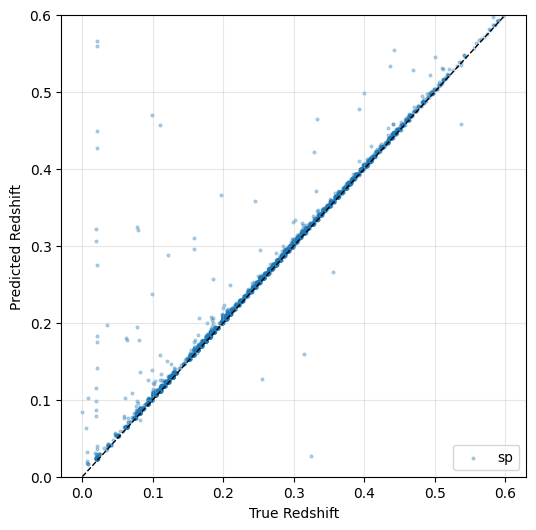

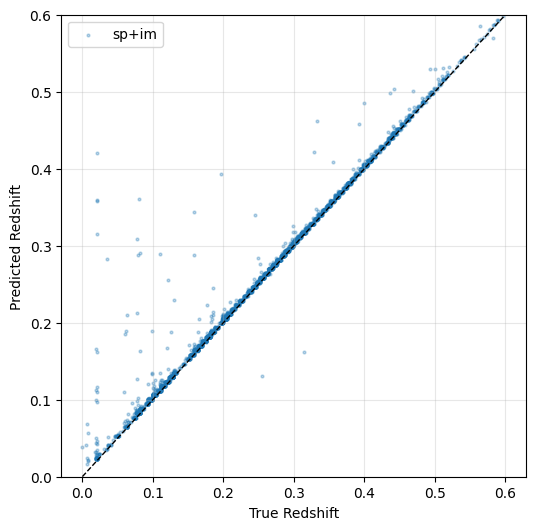

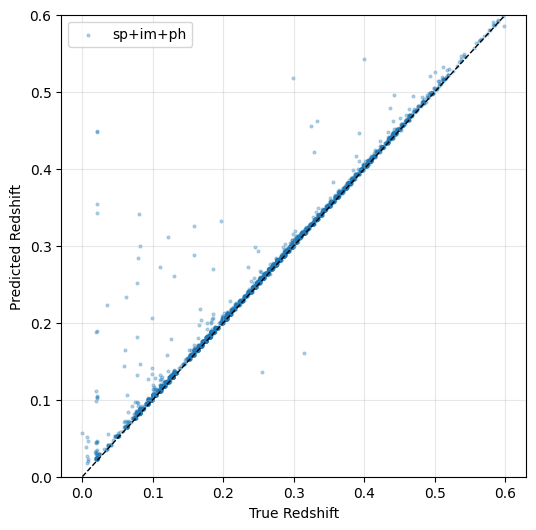

In [28]:
for task in tasks:
    plt.figure(figsize=(6,6))
    plt.scatter(df["true_z"], df[f"pred_z_{task}"], s=4, alpha=0.3, label=task)
    zmin = df["true_z"].min()
    zmax = df["true_z"].max()
    plt.plot([zmin, zmax], [zmin, zmax], "k--", linewidth=1)
    plt.xlabel("True Redshift")
    plt.ylabel("Predicted Redshift")
    plt.legend()
    plt.ylim([0, 0.6])
    plt.grid(alpha=0.3)
    plt.show()